In [ ]:
!pip install tensorflow-federated
!pip install cryptography

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 50.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of tensorflow-federated to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.3/887.3 kB 27.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of tensorflow-federated to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from cryptography.fernet import Fernet
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/heart_disease_dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,0.0,1.0,145.0,160.0,0.0,1.0,161.0,0.0,0.0,1.0,0.0,2.0,0.0
1,57.0,1.0,2.0,112.0,286.0,0.0,0.0,150.0,1.0,1.6,1.0,1.0,2.0,1.0
2,44.0,0.0,0.0,150.0,175.0,0.0,1.0,156.0,0.0,0.0,1.0,0.0,2.0,0.0
3,46.0,1.0,1.0,150.0,269.0,0.0,1.0,159.0,1.0,0.5,2.0,1.0,3.0,1.0
4,54.0,1.0,2.0,120.0,309.0,0.0,1.0,195.0,1.0,2.0,1.0,0.0,3.0,1.0


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.shape

(3235, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3235 non-null   float64
 1   sex       3235 non-null   float64
 2   cp        3235 non-null   float64
 3   trestbps  3235 non-null   float64
 4   chol      3235 non-null   float64
 5   fbs       3235 non-null   float64
 6   restecg   3235 non-null   float64
 7   thalach   3235 non-null   float64
 8   exang     3235 non-null   float64
 9   oldpeak   3235 non-null   float64
 10  slope     3235 non-null   float64
 11  ca        3235 non-null   float64
 12  thal      3235 non-null   float64
 13  target    3235 non-null   float64
dtypes: float64(14)
memory usage: 354.0 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000
mean,54.533774,0.672302,0.937447,131.798502,246.302437,0.510055,0.522574,149.116613,0.440622,1.046243,1.395919,0.742440,2.298034,0.540649
std,8.976545,0.469404,1.026009,18.004546,52.531289,0.499919,0.521011,23.212151,0.496853,1.168006,0.611208,1.023453,0.607317,0.498422
min,28.661793,-0.024556,-0.071508,93.304637,123.758968,-0.028420,-0.033105,69.617540,-0.031838,-0.074034,-0.029055,-0.087065,-0.011382,0.000000
25%,47.829891,0.006625,0.000000,119.998705,210.473903,0.000000,0.000000,132.783423,-0.000396,0.012786,0.997654,-0.001424,1.994640,0.000000
50%,55.868154,0.994835,0.973762,129.982563,240.879546,0.980413,0.979625,152.337157,0.012315,0.776862,1.015948,0.022733,2.007764,1.000000
75%,61.015992,1.002110,1.995305,140.141569,275.048038,1.000000,1.000000,165.798135,0.999695,1.772279,1.999247,1.016615,2.995372,1.000000
max,77.252090,1.032402,3.069119,200.544513,565.208396,1.032028,2.023007,202.707794,1.028932,6.228175,2.036469,4.038031,3.038514,1.000000


/tmp/ipykernel_1364/715622588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=df, palette='PuBuGn')


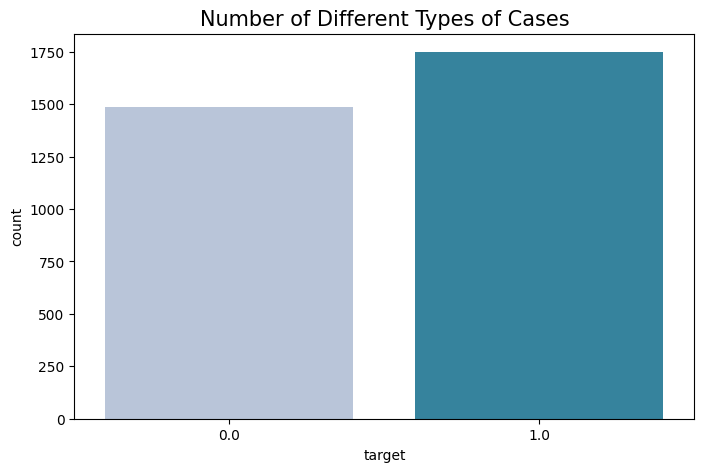

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='target',data=df, palette='PuBuGn')
plt.title('Number of Different Types of Cases', fontsize=15)
plt.show()

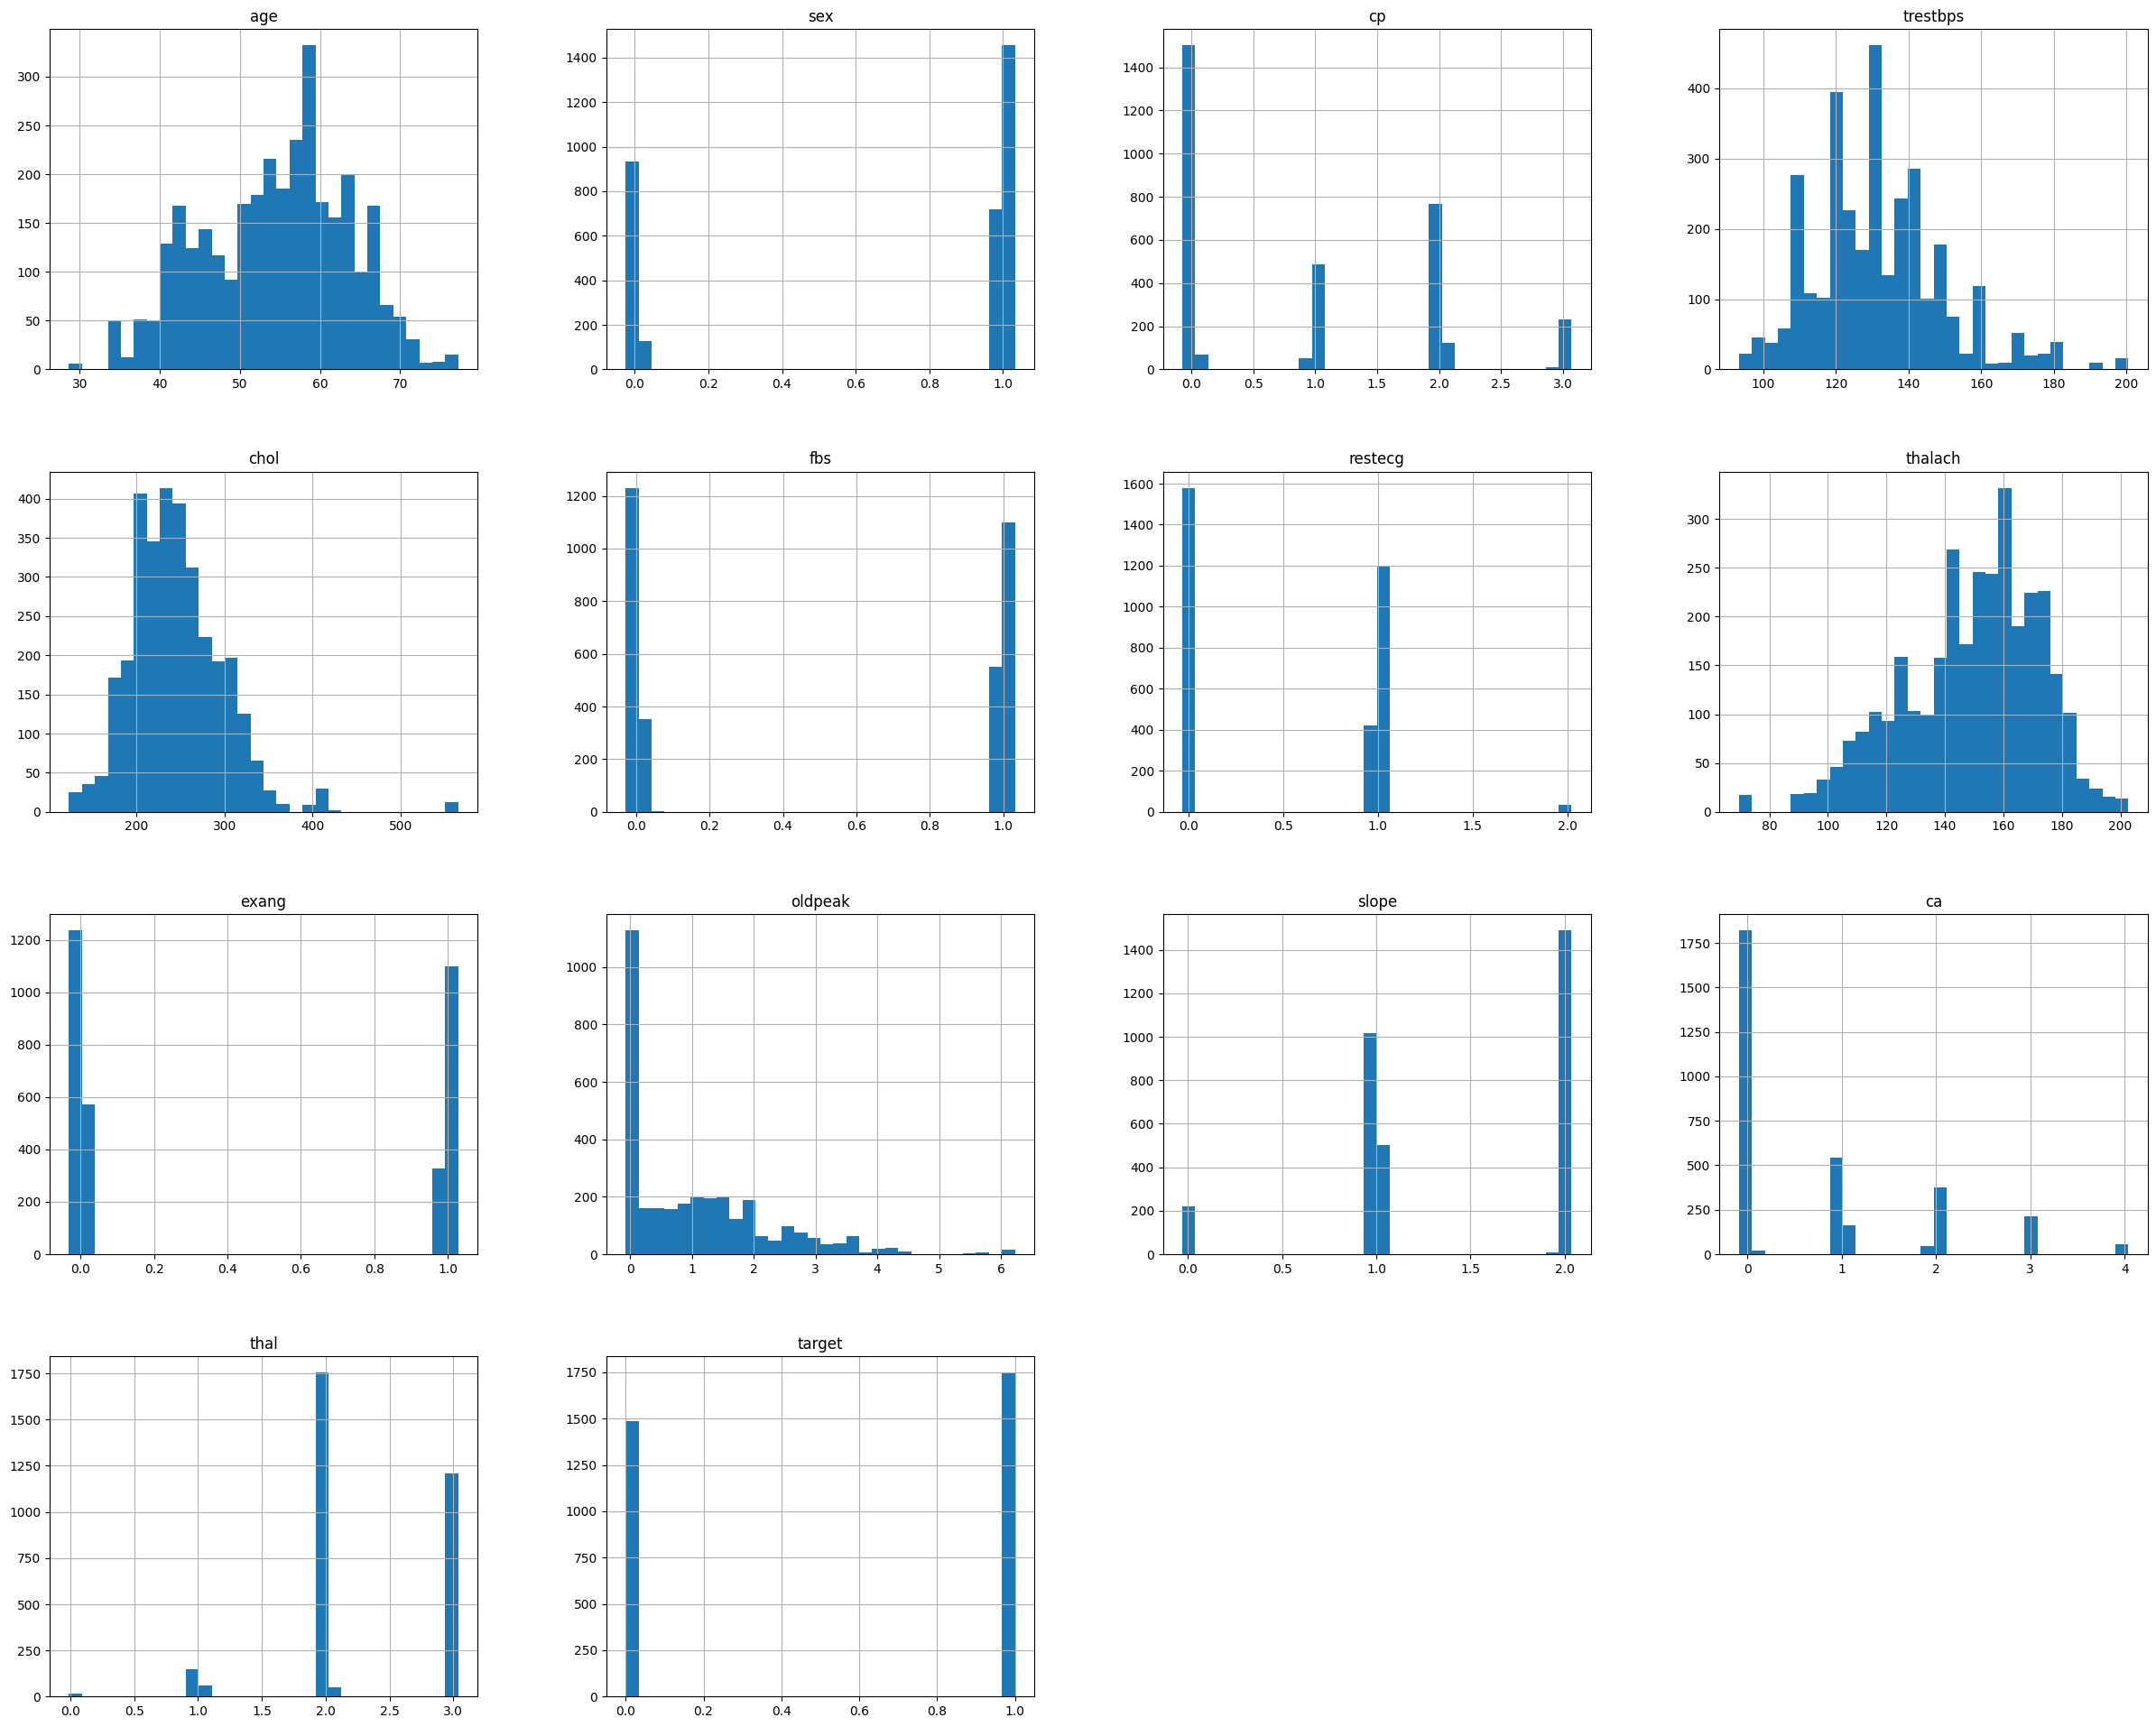

In [ ]:
df.hist(figsize=(30,24),bins = 30)
plt.title("Features Distribution")
plt.show()

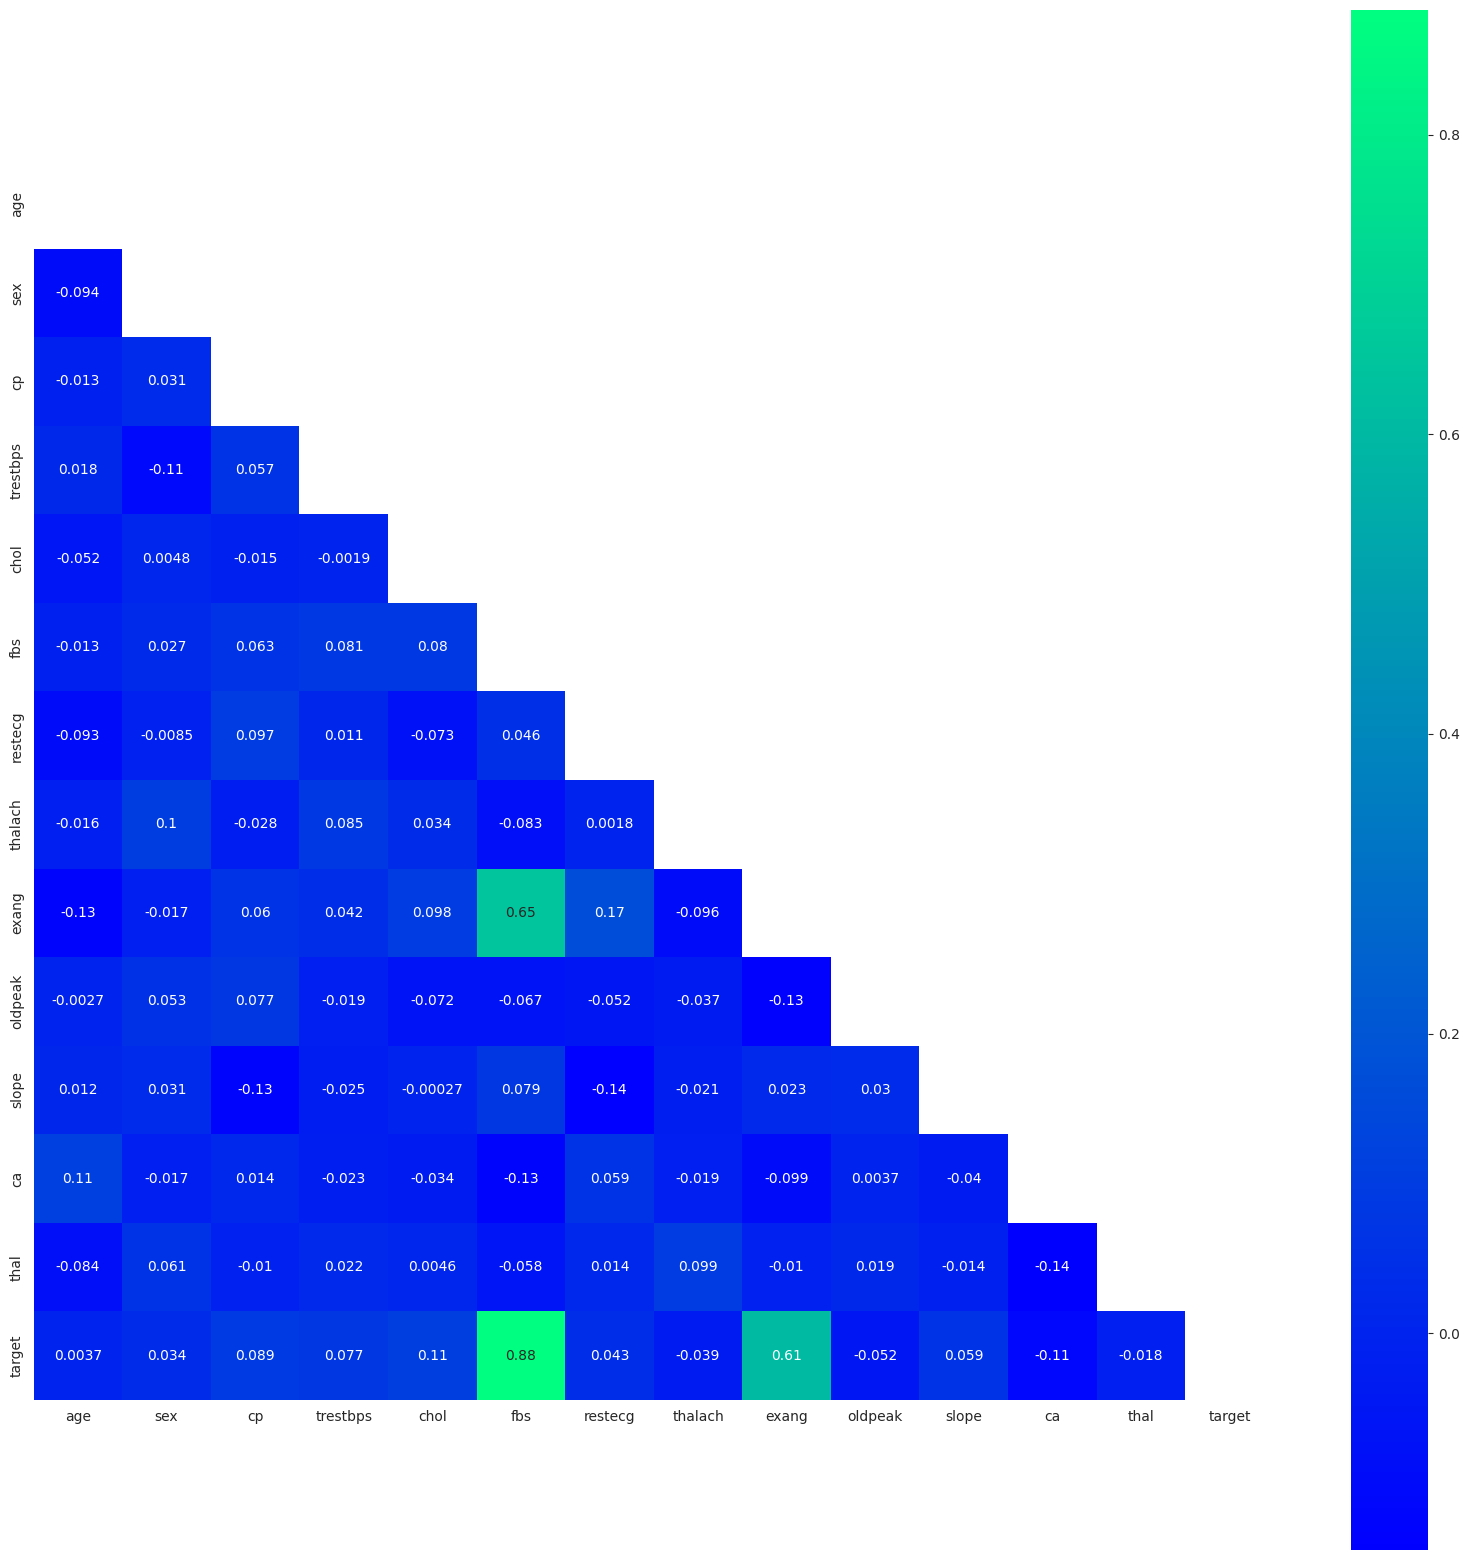

In [ ]:
plt.figure(figsize=(20,20))
corr=df.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask,square=True, annot=True, cmap='winter')

In [ ]:
X = df.drop("target", axis=1).values
y = df["target"].values

# First split the raw data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)

# Transform the test data using the training-fitted scaler
X_test = scaler.transform(X_test_raw)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2588, 13)
Test set shape: (647, 13)


In [ ]:
def create_client_data(X, y, num_clients=3):
    client_data = []
    split_size = len(X) // num_clients
    for i in range(num_clients):
        start = i * split_size
        end = (i+1) * split_size
        client_data.append((X[start:end], y[start:end]))
    return client_data

clients = create_client_data(X_train, y_train, num_clients=3)


# Hybrid Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model


# =====================================================
# Graph Attention Layer
# =====================================================
class GraphAttentionLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.W = Dense(self.units)

        self.attn = Dense(1)

    def call(self, x):

        h = self.W(x)

        scores = tf.matmul(
            h,
            h,
            transpose_b=True
        )

        scores = tf.nn.softmax(
            scores,
            axis=-1
        )

        out = tf.matmul(
            scores,
            h
        )

        return out


# =====================================================
# Graph Layer
# =====================================================
class GraphLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.proj = Dense(
            self.units,
            activation='relu'
        )

    def call(self, x):

        A = tf.matmul(
            x,
            x,
            transpose_b=True
        )

        A = tf.nn.softmax(
            A,
            axis=-1
        )

        out = tf.matmul(
            A,
            x
        )

        return self.proj(out)


# =====================================================
# GACNN MODEL
# =====================================================
def create_model():

    inputs = Input(
        shape=(X_train.shape[1],)
    )

    x = Reshape(
        (X_train.shape[1], 1)
    )(inputs)

    # =====================================
    # Multi-Scale CNN
    # =====================================

    conv3 = Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(x)

    conv5 = Conv1D(
        32,
        5,
        padding='same',
        activation='relu'
    )(x)

    x = Concatenate()([
        conv3,
        conv5
    ])

    x = BatchNormalization()(x)

    # =====================================
    # Local Graph Branch
    # =====================================

    graph_local = GraphLayer(
        64
    )(x)

    # =====================================
    # Graph Attention Branch
    # =====================================

    graph_global = GraphAttentionLayer(
        64
    )(x)

    # =====================================
    # Fusion
    # =====================================

    fusion = Concatenate()([
        graph_local,
        graph_global
    ])

    fusion = BatchNormalization()(
        fusion
    )

    # Residual connection

    residual = Conv1D(
        fusion.shape[-1],
        kernel_size=1,
        padding='same'
    )(x)

    fusion = Add()([
        fusion,
        residual
    ])

    # =====================================
    # Pooling
    # =====================================

    fusion = GlobalAveragePooling1D()(
        fusion
    )

    # =====================================
    # Dense Head
    # =====================================

    fusion = Dense(
        128,
        activation='relu'
    )(fusion)

    fusion = Dropout(
        0.3
    )(fusion)

    fusion = Dense(
        64,
        activation='relu'
    )(fusion)

    fusion = Dropout(
        0.2
    )(fusion)

    outputs = Dense(
        1,
        activation='sigmoid'
    )(fusion)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',

        ]
    )

    return model

In [ ]:
import pickle

def federated_training(clients, local_epochs=5):
    global_model = create_model()
    client_models = []   # store trained client models
    client_histories = [] # Added back client_histories

    # Encryption setup
    key = Fernet.generate_key()
    cipher = Fernet(key)
    encrypted_weights = []

    # Train clients
    for idx, (Xc, yc) in enumerate(clients):
        client_model = create_model()
        client_model.set_weights(global_model.get_weights())

        history = client_model.fit(Xc, yc, epochs=local_epochs, batch_size=8, verbose=1, validation_split=0.2)
        client_histories.append(history.history) # Append history

        # Evaluate client model
        loss_c, acc_c = client_model.evaluate(X_test, y_test, verbose=0)
        print(f"   Client {idx+1} -> Loss: {loss_c:.4f}, Accuracy: {acc_c:.4f}")

        client_models.append(client_model)

        # Encrypt weights
        # Serialize weights using pickle before encryption
        weights_bytes = pickle.dumps(client_model.get_weights())
        enc = cipher.encrypt(weights_bytes)
        encrypted_weights.append(enc)

    # Decrypt & aggregate for global model
    decrypted_weights = []
    for enc in encrypted_weights:
        dec = cipher.decrypt(enc)
        # Deserialize weights using pickle after decryption
        weights = pickle.loads(dec)
        decrypted_weights.append(weights)

    # Aggregate weights
    aggregated_weights = []
    for i in range(len(decrypted_weights[0])):
        layer_weights = np.array([client_weights[i] for client_weights in decrypted_weights])
        aggregated_weights.append(np.mean(layer_weights, axis=0))

    global_model.set_weights(aggregated_weights)

    # Evaluate global model
    loss, acc = global_model.evaluate(X_test, y_test, verbose=1)
    print(f"\n🌍 Global Model -> Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    return global_model, client_models, client_histories # Added back client_histories

In [ ]:
def plot_client_training_curves(client_histories):
    num_clients = len(client_histories)

    for i, hist in enumerate(client_histories):
        # Loss
        plt.figure(figsize=(10,5))
        plt.plot(hist['loss'], label=f"Client {i+1} Train Loss")
        plt.plot(hist['val_loss'], linestyle="--", label=f"Client {i+1} Val Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Client {i+1} Training Loss")
        plt.legend()
        plt.show()

        # Accuracy
        plt.figure(figsize=(10,5))
        plt.plot(hist['accuracy'], label=f"Client {i+1} Train Acc")
        plt.plot(hist['val_accuracy'], linestyle="--", label=f"Client {i+1} Val Acc")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title(f"Client {i+1} Training Accuracy")
        plt.legend()
        plt.show()

In [ ]:
global_model, client_models, client_histories = federated_training(clients, local_epochs=500)

Epoch 1/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.7446 - loss: 0.5409 - val_accuracy: 0.8439 - val_loss: 0.6050
Epoch 2/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8331 - loss: 0.4185 - val_accuracy: 0.8613 - val_loss: 0.5191
Epoch 3/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8302 - loss: 0.3919 - val_accuracy: 0.8613 - val_loss: 0.4349
Epoch 4/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8084 - loss: 0.3938 - val_accuracy: 0.8613 - val_loss: 0.3793
Epoch 5/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8520 - loss: 0.3648 - val_accuracy: 0.8728 - val_loss: 0.3353
Epoch 6/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8549 - loss: 0.3524 - val_accuracy: 0.8728 - val_loss: 0.3129
Epoch 7/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8476 - loss: 0.3605 - val_accuracy: 0.8728 - val_loss: 0.3051
Epoch 8/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8549 - loss: 0.3480 - val_accuracy: 0.8671 -

In [ ]:
global_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 11, 1)     │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 11, 32)    │        128 │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 11, 32)    │        192 │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 11, 64)    │          0 │ conv1d_15[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 64)    │        256 │ concatenate_10[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_layer_5       │ (None, 11, 64)    │      4,160 │ batch_normalizat… │
│ (GraphLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_attention_la… │ (None, 11, 64)    │      4,160 │ batch_normalizat… │
│ (GraphAttentionLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 11, 128)   │          0 │ graph_layer_5[0]… │
│ (Concatenate)       │                   │            │ graph_attention_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 128)   │        512 │ concatenate_11[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 11, 128)   │      8,320 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 11, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_5[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_33[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_34[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │         65 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,561 (166.25 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 384 (1.50 KB)

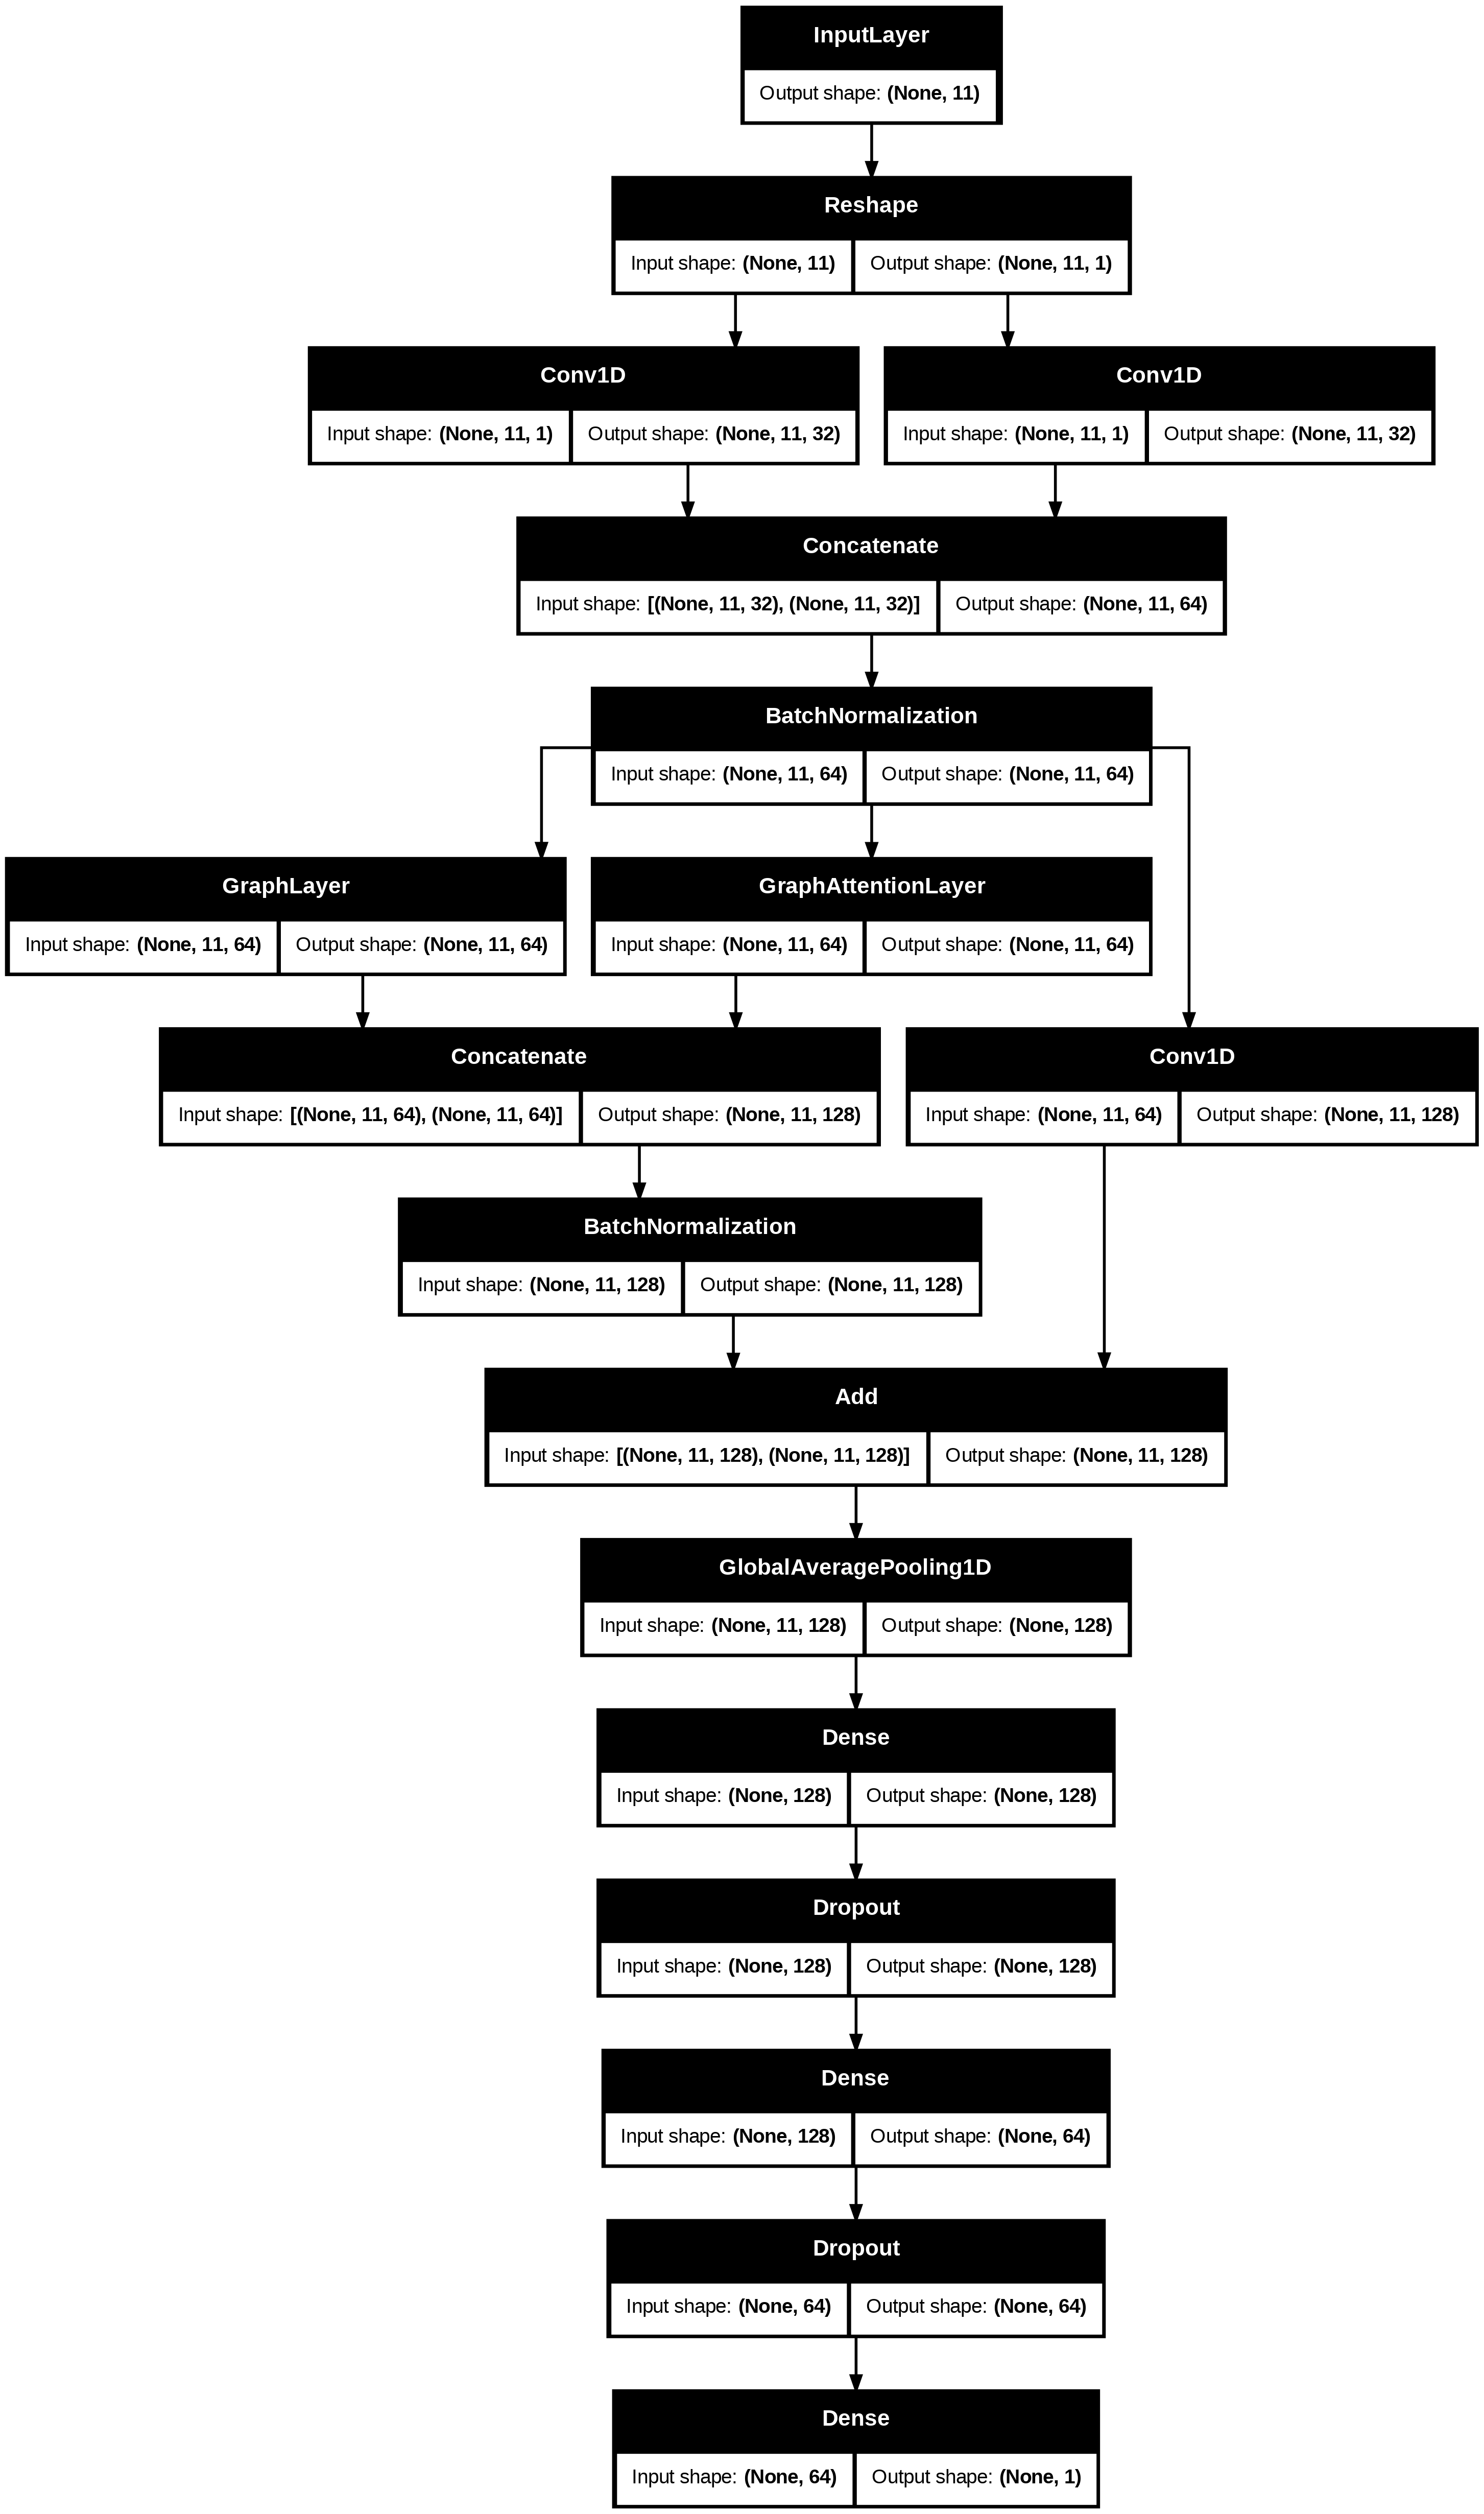

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(global_model, to_file='model.png', show_shapes=True)

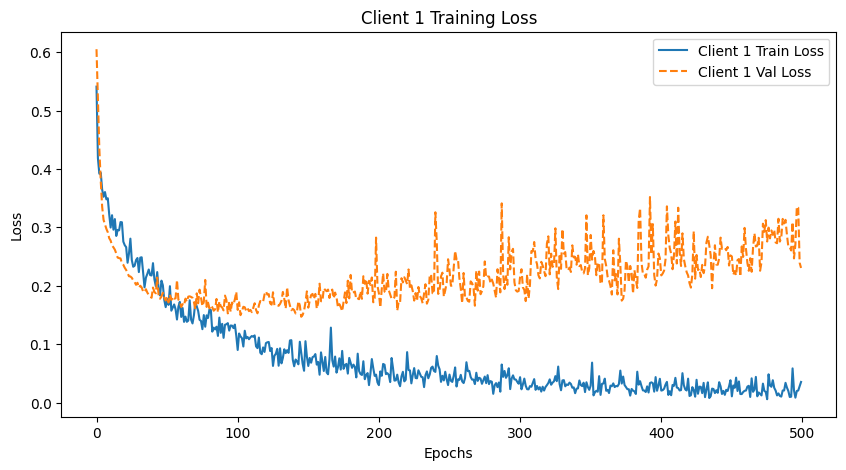

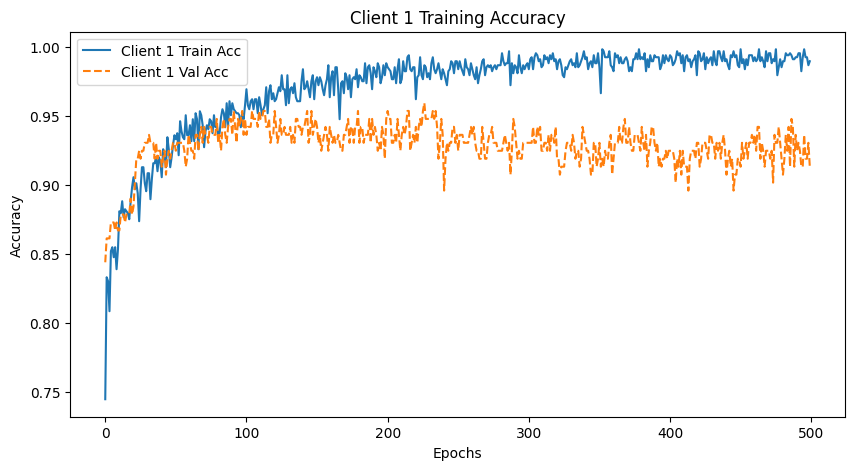

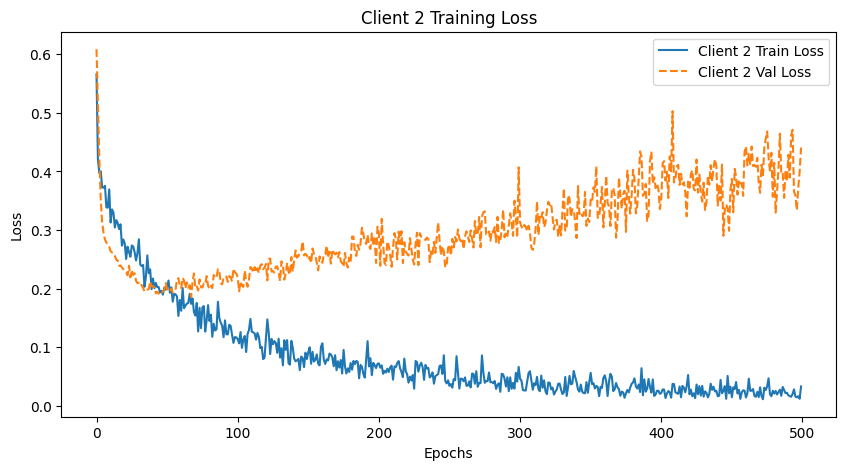

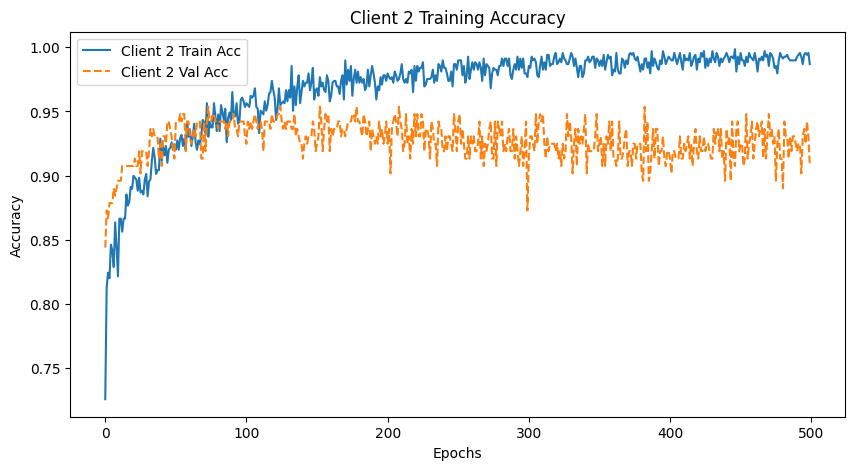

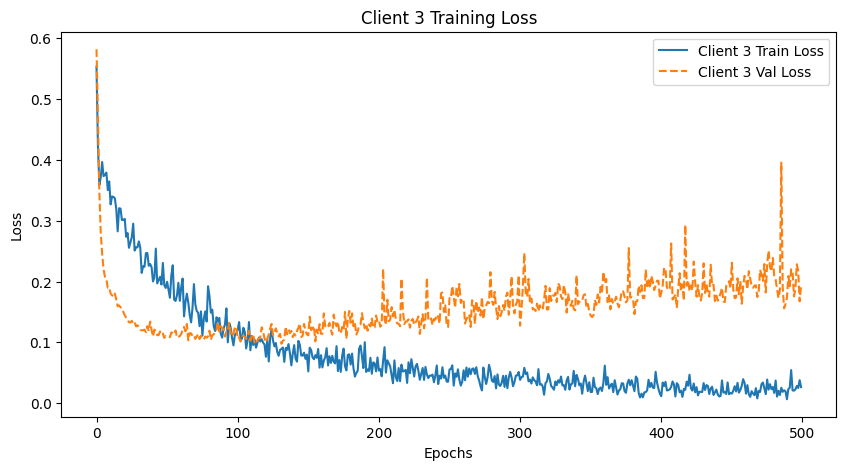

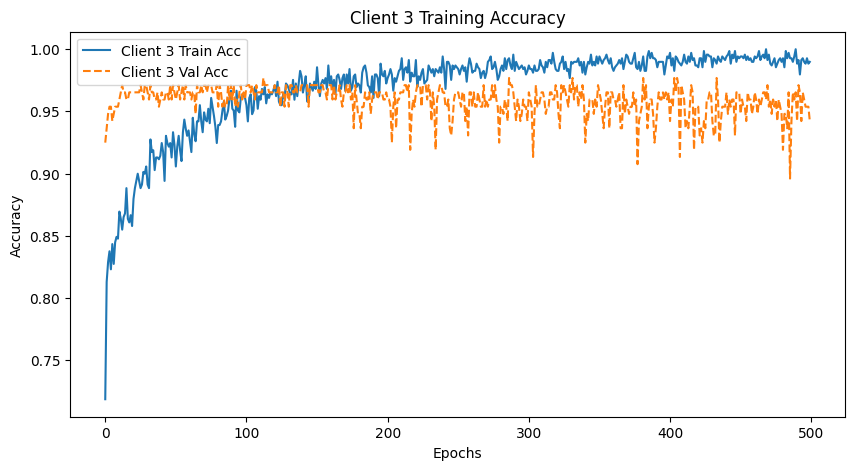

In [ ]:
def plot_client_training_curves(client_histories):
    num_clients = len(client_histories)

    for i, hist in enumerate(client_histories):
        # Loss
        plt.figure(figsize=(10,5))
        plt.plot(hist['loss'], label=f"Client {i+1} Train Loss")
        plt.plot(hist['val_loss'], linestyle="--", label=f"Client {i+1} Val Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Client {i+1} Training Loss")
        plt.legend()
        plt.show()

        # Accuracy
        plt.figure(figsize=(10,5))
        plt.plot(hist['accuracy'], label=f"Client {i+1} Train Acc")
        plt.plot(hist['val_accuracy'], linestyle="--", label=f"Client {i+1} Val Acc")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title(f"Client {i+1} Training Accuracy")
        plt.legend()
        plt.show()

# Plot curves for all clients
plot_client_training_curves(client_histories)

In [ ]:
def evaluate_model(model, name="Model"):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Classification Report
    print(f"\n📊 {name} Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Disease","Disease"], yticklabels=["No Disease","Disease"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()

In [ ]:
def evaluate_model(model, name="Model"):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Classification Report
    print(f"\n📊 {name} (Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Disease","Disease"], yticklabels=["No Disease","Disease"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📊 Client 1 (Classification Report:
              precision    recall  f1-score   support

           0     0.8985    0.9574    0.9270       305
           1     0.9596    0.9035    0.9307       342

    accuracy                         0.9289       647
   macro avg     0.9290    0.9304    0.9289       647
weighted avg     0.9308    0.9289    0.9290       647



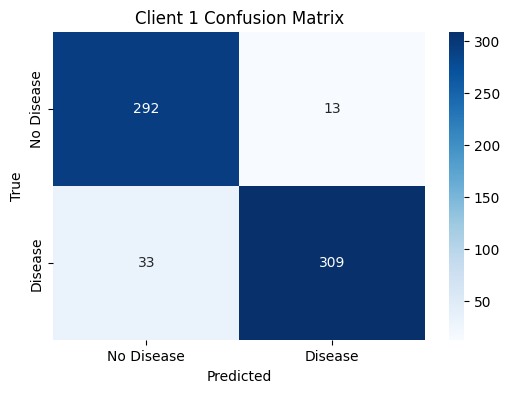

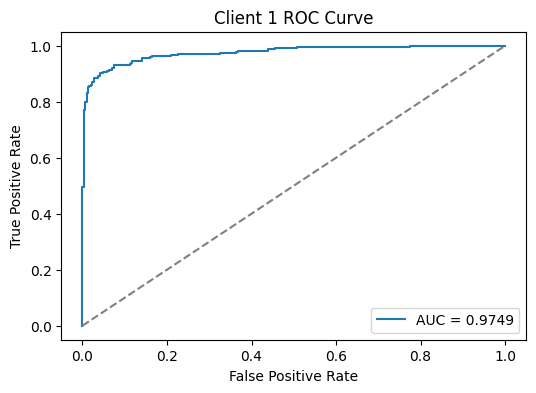

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📊 Client 2 (Classification Report:
              precision    recall  f1-score   support

           0     0.8991    0.9344    0.9164       305
           1     0.9394    0.9064    0.9226       342

    accuracy                         0.9196       647
   macro avg     0.9192    0.9204    0.9195       647
weighted avg     0.9204    0.9196    0.9197       647



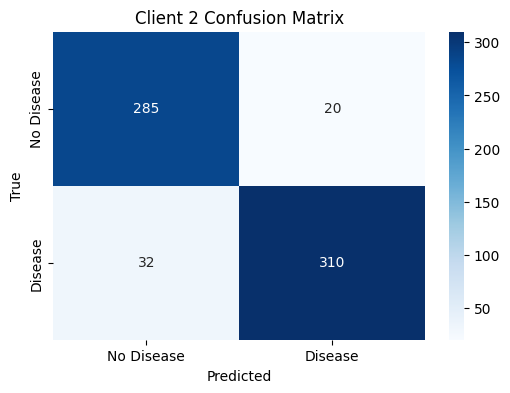

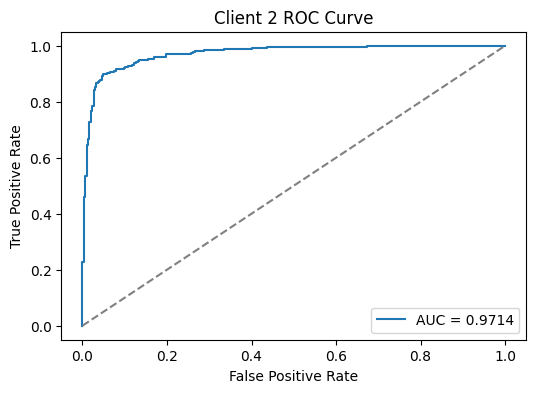

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📊 Client 3 (Classification Report:
              precision    recall  f1-score   support

           0     0.9097    0.8918    0.9007       305
           1     0.9052    0.9211    0.9130       342

    accuracy                         0.9073       647
   macro avg     0.9074    0.9064    0.9069       647
weighted avg     0.9073    0.9073    0.9072       647



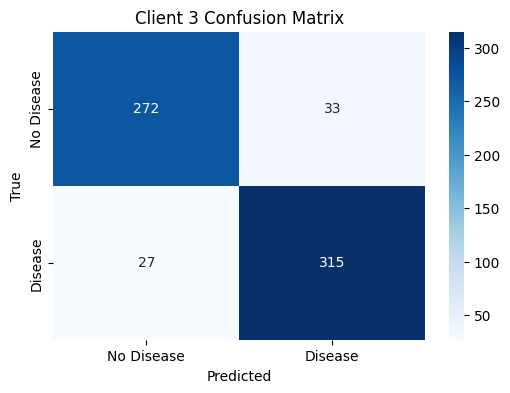

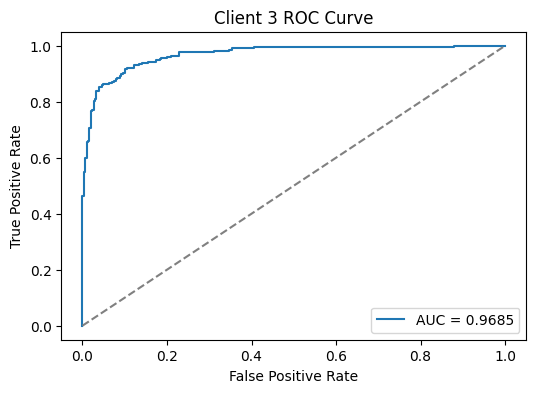

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 Global Model (Classification Report:
              precision    recall  f1-score   support

           0     0.9068    0.9574    0.9314       305
           1     0.9600    0.9123    0.9355       342

    accuracy                         0.9335       647
   macro avg     0.9334    0.9348    0.9335       647
weighted avg     0.9349    0.9335    0.9336       647



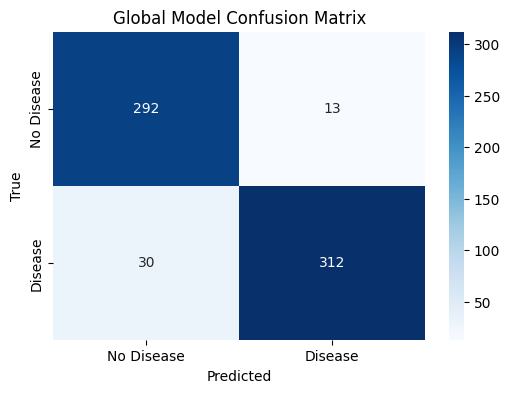

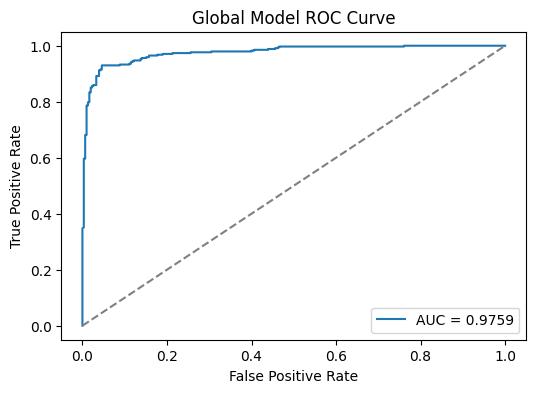

In [ ]:
# Clients
for i, client_model in enumerate(client_models):
    evaluate_model(client_model, name=f"Client {i+1}")

# Global
evaluate_model(global_model, name="Global Model")


In [ ]:
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(2588, 11)


In [ ]:
print(type(global_model))

<class 'keras.src.models.functional.Functional'>


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

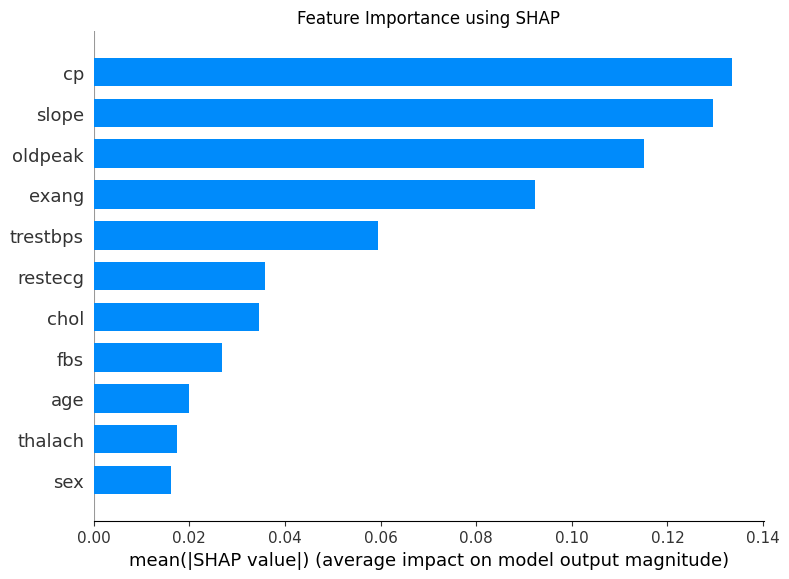

In [ ]:
# ==========================================================
# SHAP FEATURE IMPORTANCE BAR PLOT
# ==========================================================

!pip -q install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cleveland feature names
feature_names = [
    'age','sex','cp','trestbps','chol',
    'fbs','restecg','thalach','exang',
    'oldpeak','slope'
]

# Convert test data to dataframe
X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

# Small sample for SHAP
sample_data = X_test[:100]

# Background samples
background = X_train[np.random.choice(
    X_train.shape[0],
    50,
    replace=False
)]

# Create SHAP explainer
explainer = shap.KernelExplainer(
    global_model.predict,
    background
)

# Compute SHAP values
shap_values = explainer.shap_values(sample_data)

# Fix dimensions
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

print("SHAP shape:", shap_values.shape)

# If shape = (100,13,1)
if len(shap_values.shape) == 3:
    shap_values = shap_values[:,:,0]

# ==========================================================
# FEATURE IMPORTANCE BAR PLOT
# ==========================================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_df.iloc[:100],
    plot_type="bar",
    show=False
)

plt.title("Feature Importance using SHAP")
plt.tight_layout()

plt.savefig(
    "SHAP_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

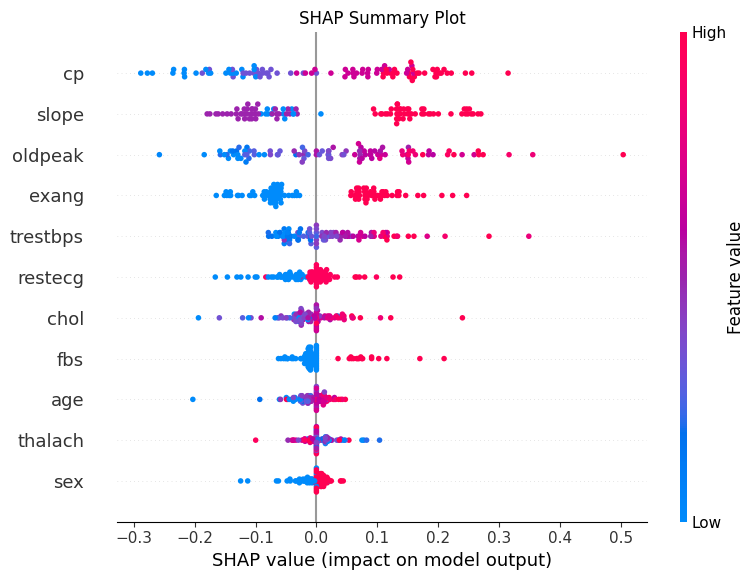

SHAP Summary Plot saved successfully


In [ ]:
# ==========================================================
# SHAP SUMMARY PLOT (BEESWARM)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Fix dimensions if needed
sv = np.array(shap_values)

if len(sv.shape) == 3:
    sv = sv[:,:,0]

plt.figure(figsize=(10,7))

shap.summary_plot(
    sv,
    X_test_df.iloc[:100],
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()

plt.savefig(
    "SHAP_Summary_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Summary Plot saved successfully")

In [ ]:
# ==========================================================
# SHAP FORCE PLOT
# ==========================================================

import shap
import numpy as np

sample_idx = 0

sv = np.array(shap_values)

# Fix dimensions if needed
if len(sv.shape) == 3:
    sv = sv[:, :, 0]

# Expected value
base_value = explainer.expected_value

if isinstance(base_value, np.ndarray):
    base_value = float(base_value[0])

# Generate force plot
force_plot = shap.force_plot(
    base_value,
    sv[sample_idx],
    X_test_df.iloc[sample_idx],
    feature_names=feature_names
)

# Save as HTML
shap.save_html(
    "SHAP_Force_Plot.html",
    force_plot
)

print("SHAP Force Plot saved as SHAP_Force_Plot.html")


from IPython.display import HTML

HTML("SHAP_Force_Plot.html")

SHAP Force Plot saved as SHAP_Force_Plot.html


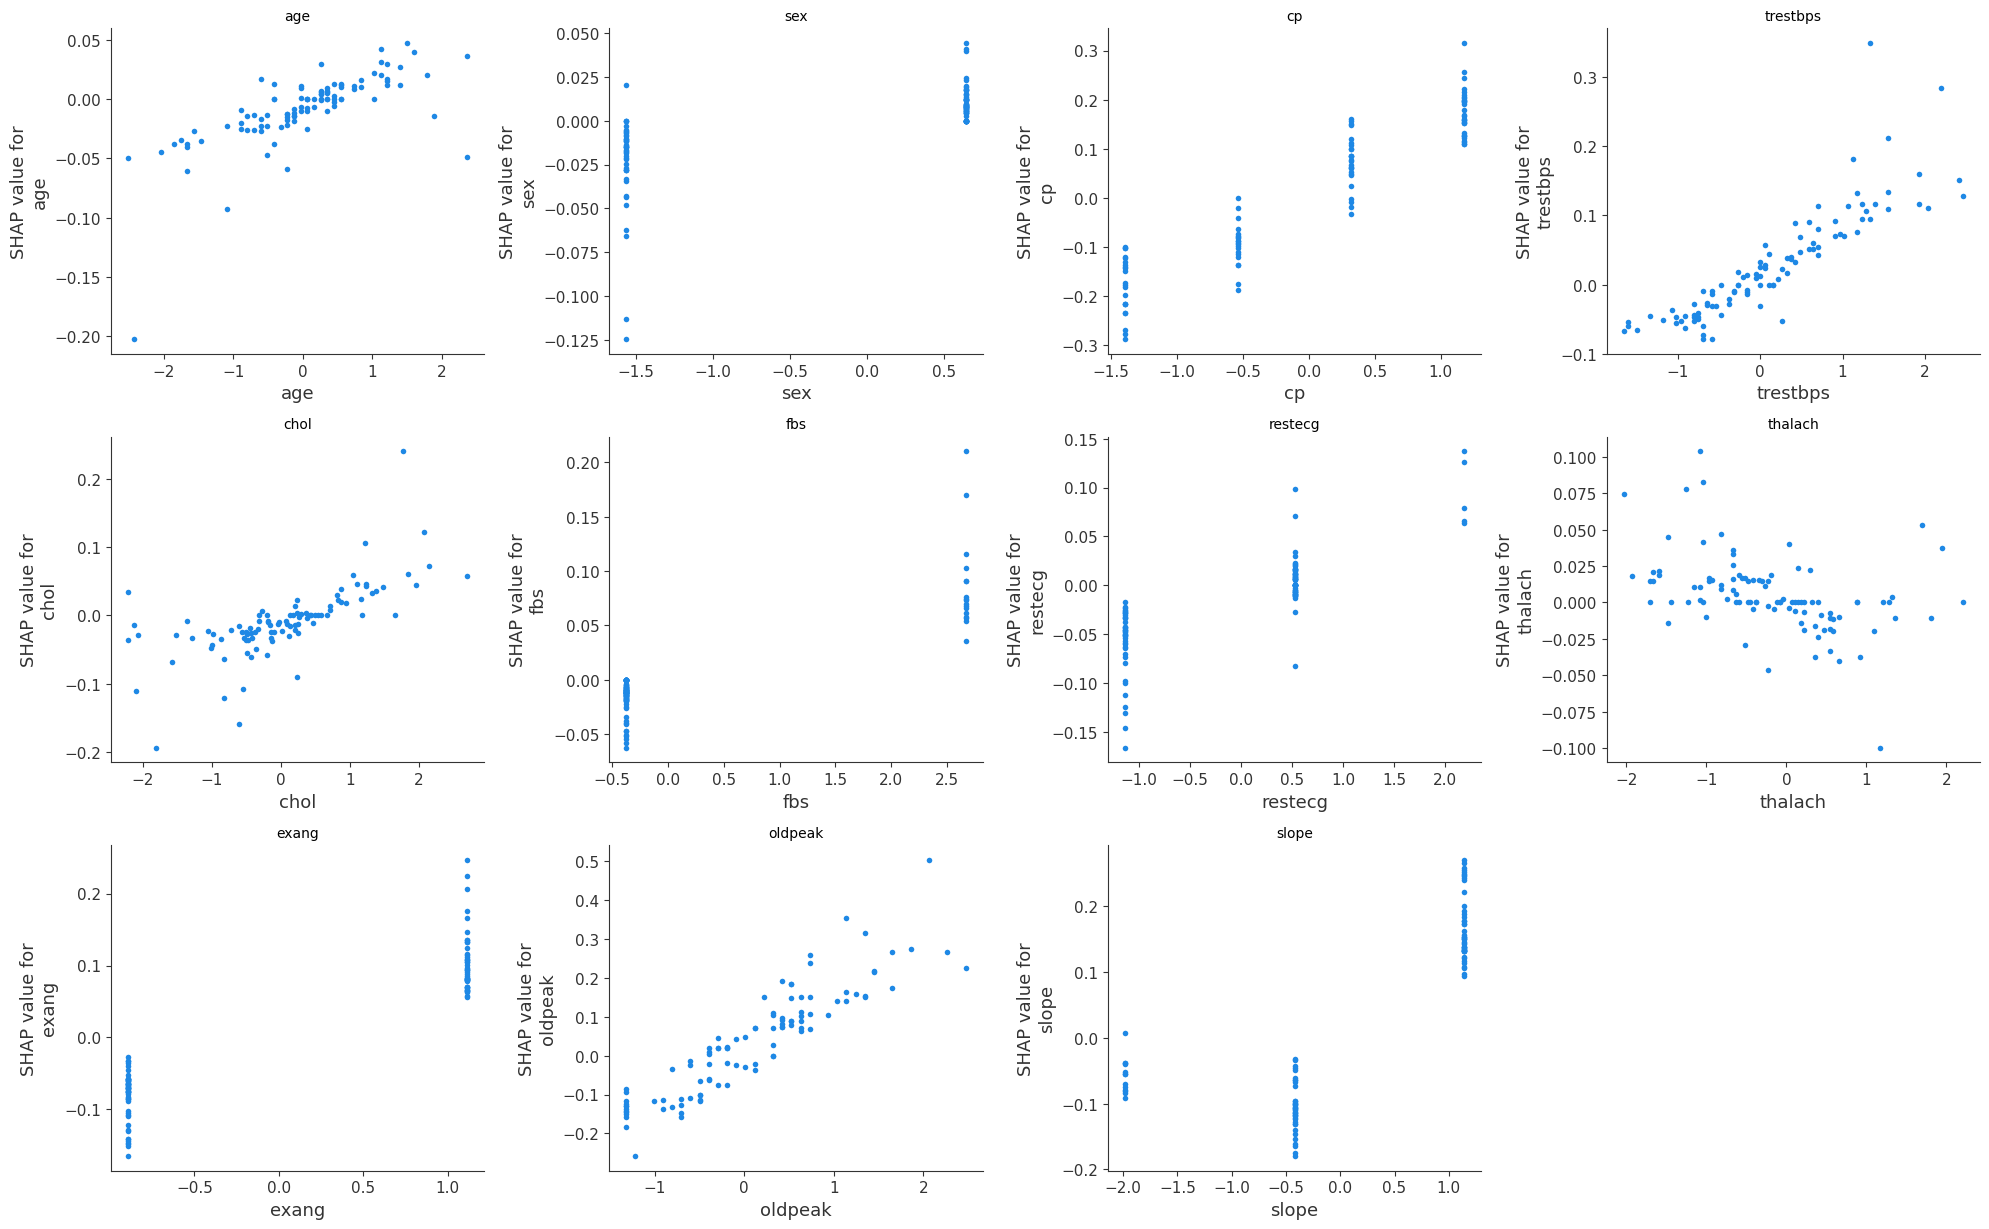

In [ ]:
# ==========================================================
# ALL SHAP DEPENDENCE PLOTS IN ONE FIGURE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import shap

sv = np.array(shap_values)

# Fix shape
if len(sv.shape) == 3:
    sv = sv[:, :, 0]

n_features = len(feature_names)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(20,16)
)

axes = axes.flatten()

for i, feature in enumerate(feature_names):

    plt.sca(axes[i])

    shap.dependence_plot(
        feature,
        sv,
        X_test_df.iloc[:100],
        feature_names=feature_names,
        interaction_index=None,
        ax=axes[i],
        show=False
    )

    axes[i].set_title(feature, fontsize=10)

# Remove unused subplot(s)
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "SHAP_All_Dependence_Plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

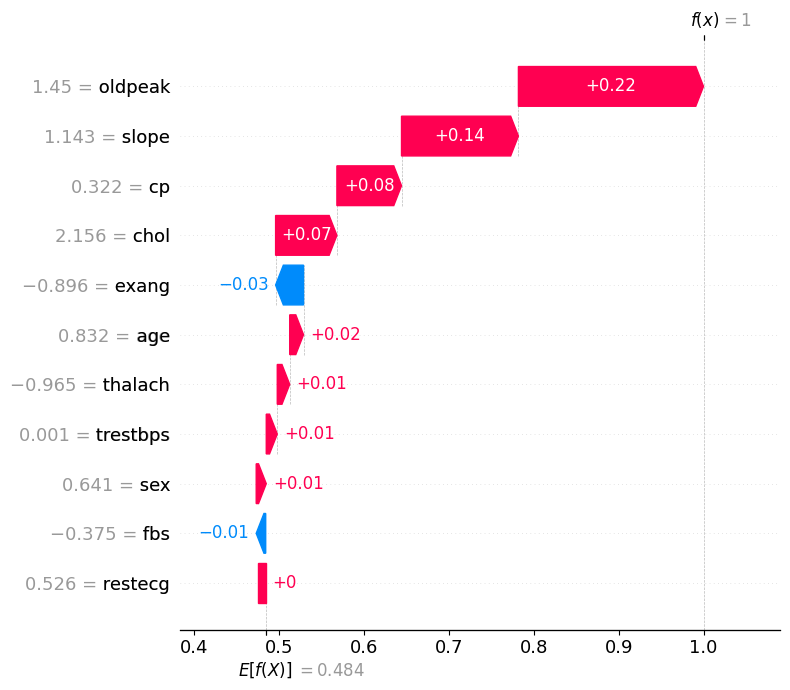

SHAP Waterfall Plot saved successfully


In [ ]:
# ==========================================================
# SHAP WATERFALL PLOT
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import shap

sample_idx = 0

sv = np.array(shap_values)

# Fix shape if needed
if len(sv.shape) == 3:
    sv = sv[:, :, 0]

# Base value
base_value = explainer.expected_value

if isinstance(base_value, np.ndarray):
    base_value = float(base_value[0])

# Create explanation object
explanation = shap.Explanation(
    values=sv[sample_idx],
    base_values=base_value,
    data=X_test_df.iloc[sample_idx].values,
    feature_names=feature_names
)

# Generate waterfall plot
plt.figure(figsize=(10,6))

shap.plots.waterfall(
    explanation,
    max_display=13,
    show=False
)

plt.tight_layout()

plt.savefig(
    "SHAP_Waterfall_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Waterfall Plot saved successfully")